In [1]:
# 1. Importimi i librarive

import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("../data/neurosense_cleaned.csv")

print(df.shape)

(37575, 361)


In [10]:
# 3. Features dhe target

X = df.drop(
    columns=["label", "subject", "session", "trial", "sample"],
    errors="ignore"
)

X = X.select_dtypes(include=["number"])

y = df["label"]

groups = df["trial"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (29820, 355)
Test: (7755, 355)


In [11]:
# 5. Random Forest Basic

rf_basic = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_basic.fit(X_train, y_train)

y_pred_rf_basic = rf_basic.predict(X_test)

In [12]:
# 6. Rezultatet Basic

rf_basic_results = {
    "Model": "Random Forest Basic",
    "Accuracy": accuracy_score(y_test, y_pred_rf_basic),
    "Precision": precision_score(y_test, y_pred_rf_basic, average="weighted"),
    "Recall": recall_score(y_test, y_pred_rf_basic, average="weighted"),
    "F1-score": f1_score(y_test, y_pred_rf_basic, average="weighted")
}

print(rf_basic_results)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_basic))

{'Model': 'Random Forest Basic', 'Accuracy': 0.3708575112830432, 'Precision': 0.41062779966342594, 'Recall': 0.3708575112830432, 'F1-score': 0.34065977064831154}

Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.58      0.49      1440
           1       0.47      0.15      0.23      3285
           2       0.30      0.73      0.42      1155
           3       0.37      0.38      0.37      1875

    accuracy                           0.37      7755
   macro avg       0.39      0.46      0.38      7755
weighted avg       0.41      0.37      0.34      7755



In [13]:
# 7. Feature Importance

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_basic.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_df.head(20)

,Feature,Importance
317,eye_feature_8,0.014648
321,eye_feature_12,0.012746
310,eye_feature_1,0.011382
345,avg_eye,0.010657
354,phys_activity,0.010022
349,eeg_eye_ratio,0.009999
315,eye_feature_6,0.009197
314,eye_feature_5,0.009175
335,eye_feature_26,0.009151
351,eye_range,0.008960


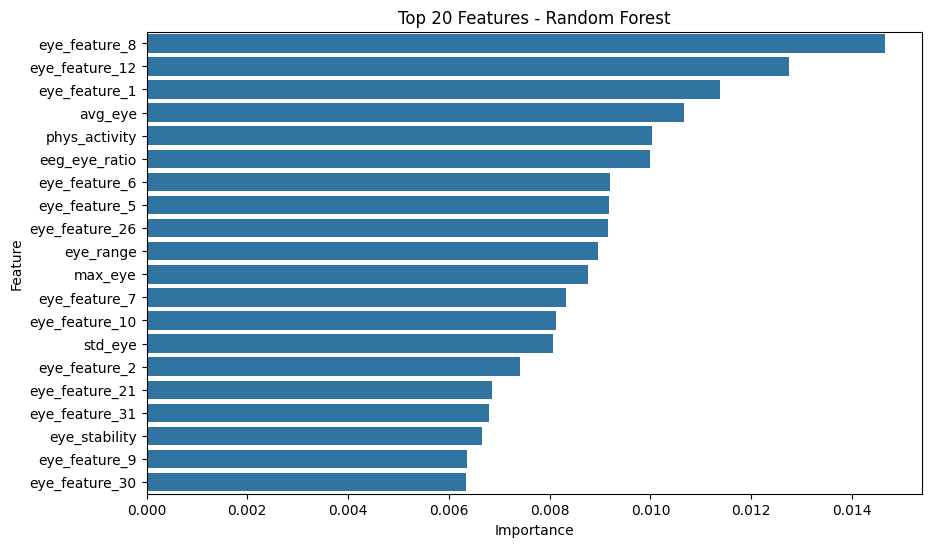

In [14]:
# 8. Top 20 Feature Importance

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance_df.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Features - Random Forest")
plt.show()

In [ ]:
# 9. Hyperparameter Tuning

param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [20, 30, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"]
}

grid_search_rf = GridSearchCV(
    RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=2
)

grid_search_rf.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search_rf.best_params_)

print("Best CV Score:")
print(grid_search_rf.best_score_)

Fitting 3 folds for each of 48 candidates, totalling 144 fits


In [ ]:
# 10. Final Evaluation

best_rf_model = grid_search_rf.best_estimator_

y_pred_best_rf = best_rf_model.predict(X_test)

rf_final_results = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_best_rf),
    "Precision": precision_score(y_test, y_pred_best_rf, average="weighted"),
    "Recall": recall_score(y_test, y_pred_best_rf, average="weighted"),
    "F1-score": f1_score(y_test, y_pred_best_rf, average="weighted"),
    "Best Parameters": grid_search_rf.best_params_
}

rf_final_results

              precision    recall  f1-score   support

           0       0.38      0.50      0.43      1950
           1       0.31      0.46      0.37      1905
           2       0.49      0.37      0.42      1947
           3       0.59      0.22      0.32      1713

    accuracy                           0.39      7515
   macro avg       0.44      0.39      0.39      7515
weighted avg       0.44      0.39      0.39      7515



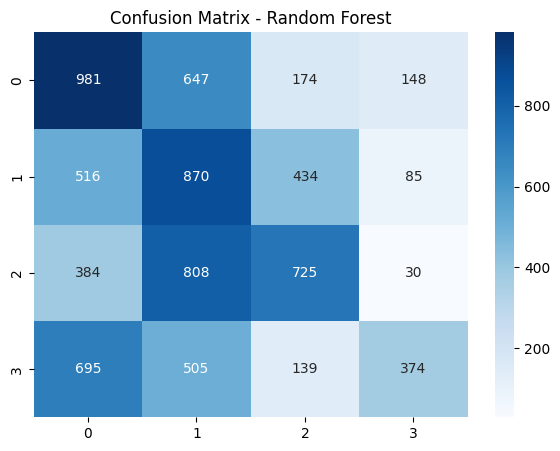

,Model,Accuracy,Precision,Recall,F1-score,Best Parameters
0,Random Forest,0.392548,0.438182,0.392548,0.388067,"{'max_depth': None, 'min_samples_leaf': 2, 'mi..."


In [ ]:
# 11. Classification Report

print(classification_report(
    y_test,
    y_pred_best_rf
))
# 12. Confusion Matrix

cm = confusion_matrix(
    y_test,
    y_pred_best_rf
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Random Forest")
plt.show()